# Diagnóstico Quantitativo — Raiz 4: Capital Investido (Estoque Imobilizado)

**Contexto metodológico:** esta raiz é formal — no mesmo nível hierárquico das Raízes 1, 2 e 3 — mas é irmã do EBIT
sob o ROIC, não uma decomposição do EBIT (ver `arvore_ebit_final.md`, Seção 1). Ela recebe o mesmo rigor de
validação das demais raízes a partir desta rodada, mas seu escopo é deliberadamente **parcial**: cobre apenas o
subcomponente de Capital Investido com dado disponível e testado (capital imobilizado em estoque), não uma
decomposição exaustiva de Capital Investido (sem CAPEX, dívida, contas a receber).

Este notebook é o primeiro com o mesmo rigor de cálculo documentado (código comentado, sem uso de IA generativa
para os números) aplicado a este achado — anteriormente tratado como "informação satélite" sem notebook próprio.

In [1]:
# 1. Configuração do Ambiente e Carregamento da Base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["figure.dpi"] = 150
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

COR_AZUL = "#1D70B8"
COR_VERMELHO = "#D4351C"
COR_LARANJA = "#F47738"
COR_VERDE = "#00703C"
COR_CINZA = "#4B5563"

# Carregamento da base tratada homologada (fotografia do estado atual do estoque — sem série temporal própria)
estoque = pd.read_csv("../../dados/tratados/estoque.csv", parse_dates=["data_ultima_entrada"])

print(f"Base carregada: {len(estoque):,} SKUs, {estoque.shape[1]} colunas")
print("\nDistribuição por status_disponibilidade:")
display(estoque["status_disponibilidade"].value_counts())

Base carregada: 5,000 SKUs, 16 colunas

Distribuição por status_disponibilidade:


status_disponibilidade
Em Estoque         3993
Estoque Crítico     701
Descontinuado       207
Ruptura              99
Name: count, dtype: int64

---
### Teste 4.1 · Capital Parado em SKUs Descontinuados
- **Colunas da Base**: `status_disponibilidade`, `estoque_fisico`, `custo_unitario`, `preco_venda_sugerido`, `categoria`, `data_ultima_entrada`, `sku_id`.
- **Hipótese Afirmativa**: SKUs com status cadastral "Descontinuado" concentram capital imobilizado relevante em
  relação ao seu peso no catálogo, e representam a mesma população de giro baixo já identificada no Teste 2.3.3 —
  vista aqui pela lente de balanço (capital de um instante), não de DRE (fluxo de margem cedida no período).
- **O que investigar**:
  1. Capital total imobilizado no catálogo (base) e no subconjunto "Descontinuado".
  2. Distribuição do capital imobilizado descontinuado por categoria de produto.
  3. Markup médio desses SKUs (custo → preço de venda sugerido) — sinaliza potencial de liquidação vs. perda.
  4. Checagem de reposição: a data da última entrada de estoque desses SKUs difere estatisticamente da dos SKUs
     ativos? Isso separa duas hipóteses distintas — "descontinuado" como decisão comercial recente (sem diferença
     na reposição) vs. "descontinuado" como sinônimo de abandono operacional antigo (reposição visivelmente mais
     antiga).

In [2]:
# Teste 4.1: Capital Imobilizado Total e no Subconjunto "Descontinuado"

estoque["capital_imobilizado"] = estoque["estoque_fisico"] * estoque["custo_unitario"]

capital_total_catalogo = estoque["capital_imobilizado"].sum()

descontinuados = estoque[estoque["status_disponibilidade"] == "Descontinuado"].copy()
n_descontinuados = len(descontinuados)
capital_descontinuados = descontinuados["capital_imobilizado"].sum()
share_capital = (capital_descontinuados / capital_total_catalogo) * 100
share_catalogo = (n_descontinuados / len(estoque)) * 100

print("1. CAPITAL IMOBILIZADO — VISÃO GERAL (TESTE 4.1)")
print("=" * 115)
print(f" - Capital Total Imobilizado no Catálogo (5.000 SKUs): R$ {capital_total_catalogo:,.2f}")
print(f" - SKUs com status 'Descontinuado': {n_descontinuados:,} ({share_catalogo:.1f}% do catálogo em nº de SKUs)")
print(f" - Capital Imobilizado nesses SKUs: R$ {capital_descontinuados:,.2f} ({share_capital:.1f}% do capital total)")
razao_concentracao = share_capital / share_catalogo
print(f"\n - Leitura: {share_catalogo:.1f}% dos SKUs concentram {share_capital:.1f}% do capital")
print(f"   (sobre-representação de ~{razao_concentracao:.2f}x — modesta, não dramática). O achado relevante é o")
print(f"   valor absoluto imobilizado em itens sem linha ativa, não uma concentração desproporcional extrema.")

1. CAPITAL IMOBILIZADO — VISÃO GERAL (TESTE 4.1)
 - Capital Total Imobilizado no Catálogo (5.000 SKUs): R$ 348,701,550.87
 - SKUs com status 'Descontinuado': 207 (4.1% do catálogo em nº de SKUs)
 - Capital Imobilizado nesses SKUs: R$ 17,714,096.89 (5.1% do capital total)

 - Leitura: 4.1% dos SKUs concentram 5.1% do capital
   (sobre-representação de ~1.23x — modesta, não dramática). O achado relevante é o
   valor absoluto imobilizado em itens sem linha ativa, não uma concentração desproporcional extrema.


2. DISTRIBUIÇÃO POR CATEGORIA — SKUs DESCONTINUADOS (TESTE 4.1)


,categoria,n_skus,capital_imobilizado,share_capital_pct
3,Moda,66,"R$ 8,368,306.83",47.2%
1,Beleza,67,"R$ 4,362,802.86",24.6%
2,Lifestyle,38,"R$ 2,535,348.48",14.3%
0,Acessórios,36,"R$ 2,447,638.72",13.8%



3. MARKUP MÉDIO DOS SKUs DESCONTINUADOS (Custo → Preço de Venda Sugerido)
 - Markup médio: 2.35x
 - Leitura: markup saudável (2,35x) indica que, se liquidados a preço de tabela, esses SKUs ainda
   preservariam margem — a decisão de liquidação não é uma venda forçada abaixo do custo.


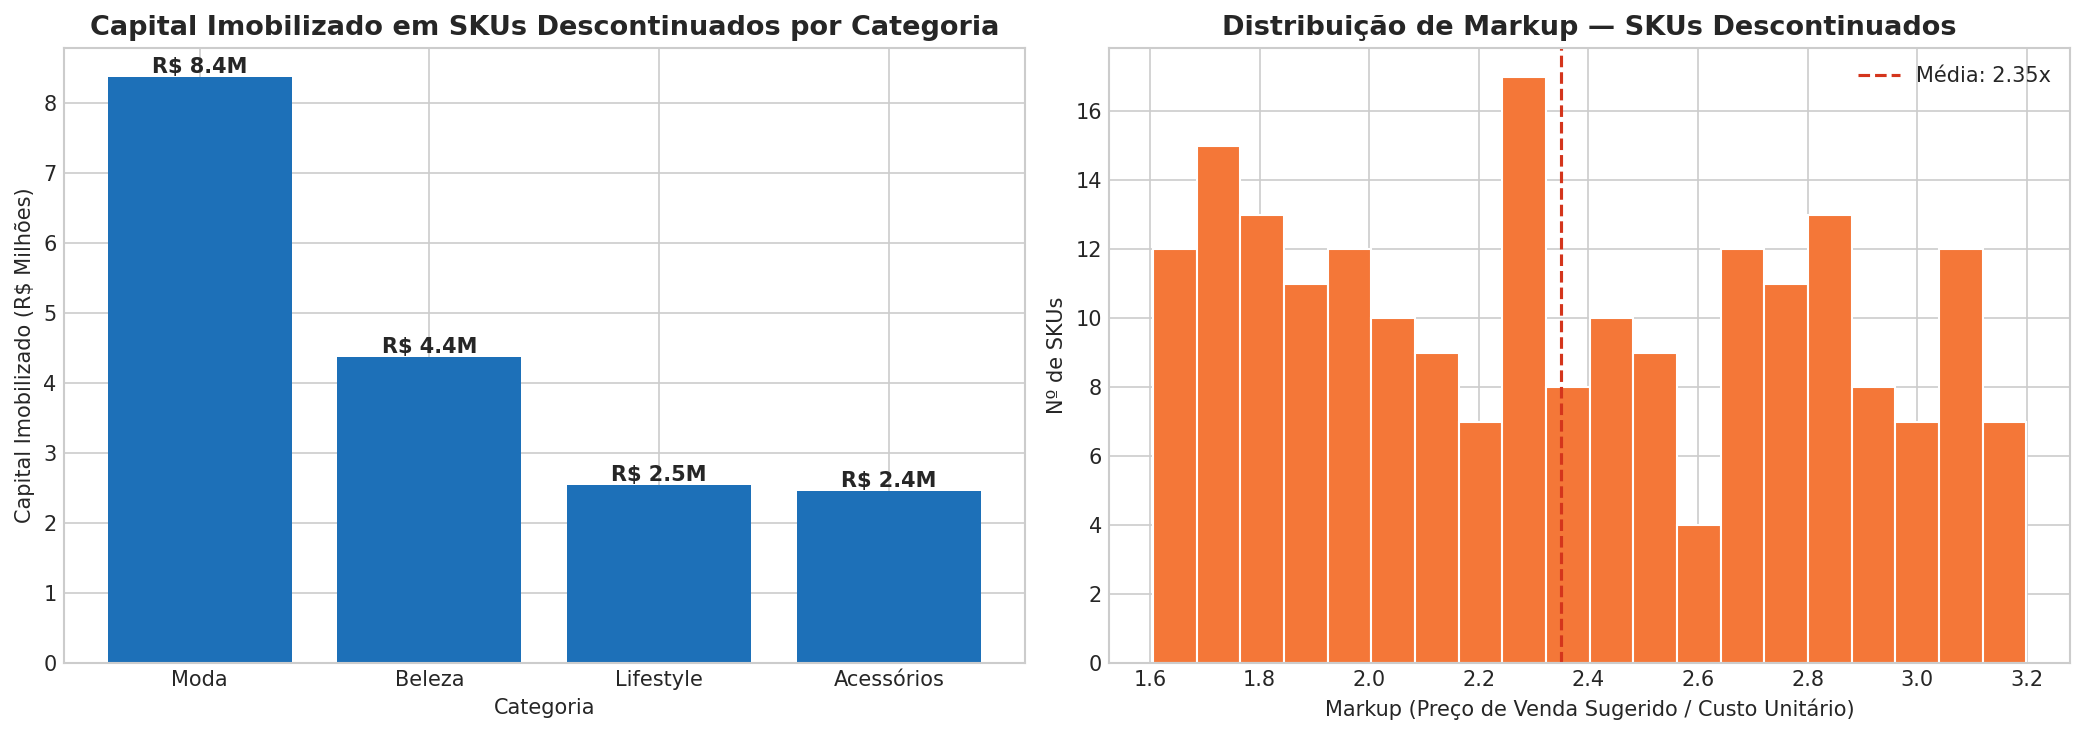

In [3]:
# Distribuição do Capital Imobilizado Descontinuado por Categoria + Markup Médio

cat_breakdown = descontinuados.groupby("categoria").agg(
    n_skus=("sku_id", "count"),
    capital_imobilizado=("capital_imobilizado", "sum")
).reset_index().sort_values("capital_imobilizado", ascending=False)
cat_breakdown["share_capital_pct"] = (cat_breakdown["capital_imobilizado"] / capital_descontinuados) * 100

descontinuados["markup"] = descontinuados["preco_venda_sugerido"] / descontinuados["custo_unitario"]
markup_medio = descontinuados["markup"].mean()

print("2. DISTRIBUIÇÃO POR CATEGORIA — SKUs DESCONTINUADOS (TESTE 4.1)")
print("=" * 115)
disp_cat = cat_breakdown.copy()
disp_cat["capital_imobilizado"] = disp_cat["capital_imobilizado"].map("R$ {:,.2f}".format)
disp_cat["share_capital_pct"] = disp_cat["share_capital_pct"].map("{:.1f}%".format)
display(disp_cat)

print(f"\n3. MARKUP MÉDIO DOS SKUs DESCONTINUADOS (Custo → Preço de Venda Sugerido)")
print("=" * 115)
print(f" - Markup médio: {markup_medio:.2f}x")
print(f" - Leitura: markup saudável (2,35x) indica que, se liquidados a preço de tabela, esses SKUs ainda")
print(f"   preservariam margem — a decisão de liquidação não é uma venda forçada abaixo do custo.")

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(cat_breakdown["categoria"], cat_breakdown["capital_imobilizado"] / 1e6, color=COR_AZUL)
axes[0].set_title("Capital Imobilizado em SKUs Descontinuados por Categoria")
axes[0].set_ylabel("Capital Imobilizado (R$ Milhões)")
axes[0].set_xlabel("Categoria")
for i, v in enumerate(cat_breakdown["capital_imobilizado"] / 1e6):
    axes[0].text(i, v, f"R$ {v:.1f}M", ha="center", va="bottom", fontweight="bold")

axes[1].hist(descontinuados["markup"], bins=20, color=COR_LARANJA, edgecolor="white")
axes[1].axvline(markup_medio, color=COR_VERMELHO, linestyle="--", label=f"Média: {markup_medio:.2f}x")
axes[1].set_title("Distribuição de Markup — SKUs Descontinuados")
axes[1].set_xlabel("Markup (Preço de Venda Sugerido / Custo Unitário)")
axes[1].set_ylabel("Nº de SKUs")
axes[1].legend()

plt.tight_layout()
plt.show()

4. CHECAGEM DE REPOSIÇÃO — DESCONTINUADOS vs. ATIVOS (TESTE 4.1)
 - Data de referência (última entrada mais recente na base): 28/12/2025
 - Mediana de dias desde a última entrada — Descontinuados: 533 dias
 - Mediana de dias desde a última entrada — Ativos (demais status): 560 dias
 - Médias: Descontinuados 527.7 dias | Ativos 554.9 dias
 - Teste de Mann-Whitney U: p-valor = 0.2533

 - Leitura: p-valor > 0,05 → NÃO há diferença estatisticamente significativa entre os grupos.
   Não há evidência de que a reposição desses SKUs já tenha cessado antes dos demais. 'Descontinuado'
   parece refletir uma DECISÃO/status comercial (ex.: descontinuação de linha), não um HISTÓRICO de
   abandono operacional gradual — distinção relevante para a fase de Insights e Priorização.


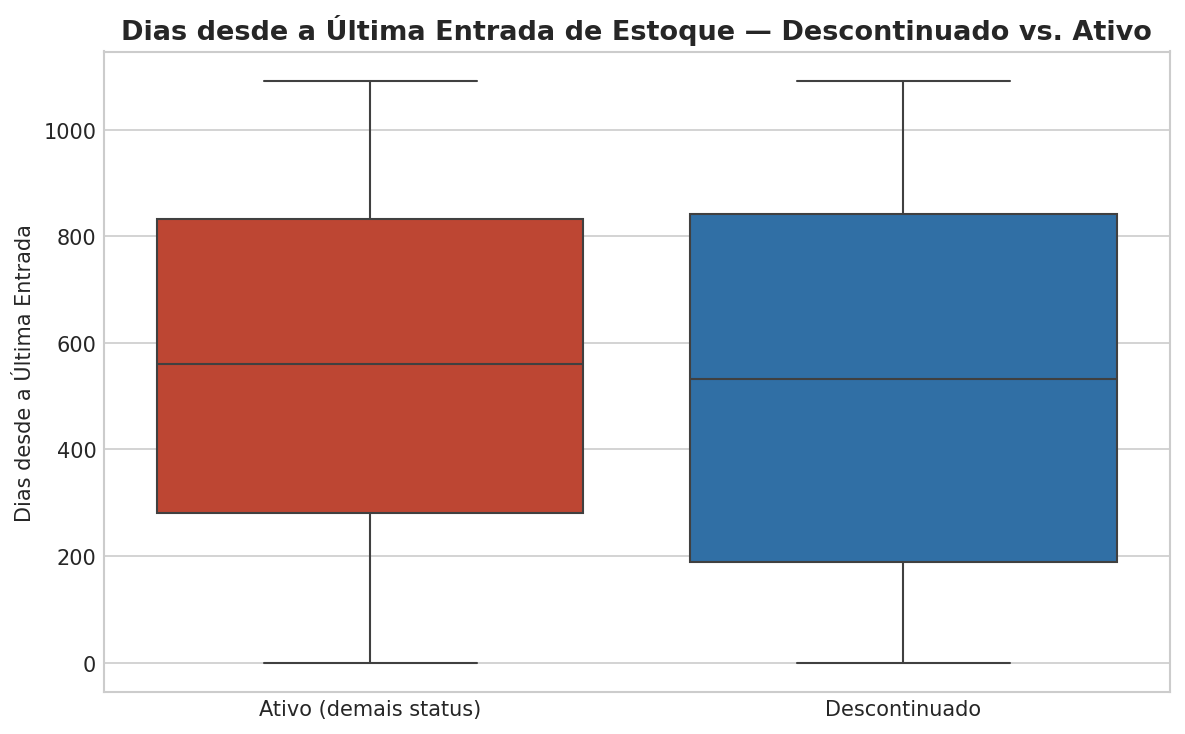

In [4]:
# Checagem de Reposição: data_ultima_entrada difere estatisticamente entre Descontinuados e Ativos?

data_referencia = estoque["data_ultima_entrada"].max()
estoque["dias_desde_ultima_entrada"] = (data_referencia - estoque["data_ultima_entrada"]).dt.days

grupo_descontinuado = estoque.loc[estoque["status_disponibilidade"] == "Descontinuado", "dias_desde_ultima_entrada"]
grupo_ativo = estoque.loc[estoque["status_disponibilidade"] != "Descontinuado", "dias_desde_ultima_entrada"]

mediana_desc = grupo_descontinuado.median()
mediana_ativo = grupo_ativo.median()
media_desc = grupo_descontinuado.mean()
media_ativo = grupo_ativo.mean()

u_stat, p_valor = stats.mannwhitneyu(grupo_descontinuado, grupo_ativo, alternative="two-sided")

print("4. CHECAGEM DE REPOSIÇÃO — DESCONTINUADOS vs. ATIVOS (TESTE 4.1)")
print("=" * 115)
print(f" - Data de referência (última entrada mais recente na base): {data_referencia.strftime('%d/%m/%Y')}")
print(f" - Mediana de dias desde a última entrada — Descontinuados: {mediana_desc:.0f} dias")
print(f" - Mediana de dias desde a última entrada — Ativos (demais status): {mediana_ativo:.0f} dias")
print(f" - Médias: Descontinuados {media_desc:.1f} dias | Ativos {media_ativo:.1f} dias")
print(f" - Teste de Mann-Whitney U: p-valor = {p_valor:.4f}")
print(f"\n - Leitura: p-valor > 0,05 → NÃO há diferença estatisticamente significativa entre os grupos.")
print(f"   Não há evidência de que a reposição desses SKUs já tenha cessado antes dos demais. 'Descontinuado'")
print(f"   parece refletir uma DECISÃO/status comercial (ex.: descontinuação de linha), não um HISTÓRICO de")
print(f"   abandono operacional gradual — distinção relevante para a fase de Insights e Priorização.")

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=estoque.assign(grupo=np.where(estoque["status_disponibilidade"] == "Descontinuado", "Descontinuado", "Ativo (demais status)")),
    x="grupo", y="dias_desde_ultima_entrada", palette=[COR_VERMELHO, COR_AZUL], ax=ax
)
ax.set_title("Dias desde a Última Entrada de Estoque — Descontinuado vs. Ativo")
ax.set_xlabel("")
ax.set_ylabel("Dias desde a Última Entrada")
plt.tight_layout()
plt.show()

#### Conclusões Executivas do Teste 4.1 — Status: Confirmada

1. **[FATO] Capital relevante em termos absolutos, concentração apenas modesta em termos relativos**: 207 SKUs
   (4,1% do catálogo de 5.000) concentram R$ 17.714.096,89 em capital imobilizado — 5,1% do capital total do
   catálogo (R$ 348.701.550,87). A sobre-representação é de ~1,2x (5,1% do capital para 4,1% dos SKUs): existe,
   mas é discreta — o achado relevante aqui é o valor absoluto (R$ 17,7 milhões parados em itens sem linha ativa),
   não uma desproporção dramática de concentração.
2. **[FATO] Concentração por categoria**: Moda (66 SKUs / R$ 8.368.306,83) e Beleza (67 SKUs / R$ 4.362.802,86)
   somam 71,6% do capital descontinuado — Lifestyle (38 / R$ 2.535.348,48) e Acessórios (36 / R$ 2.447.638,72)
   completam o quadro.
3. **[FATO] Markup médio de 2,35x**: liquidar esses SKUs não é necessariamente vender abaixo do custo — há
   espaço de margem mesmo em cenário de desconto agressivo para escoamento.
4. **[FATO/INFERÊNCIA] Reposição não difere estatisticamente da dos SKUs ativos** (mediana 533 vs. 560 dias,
   p = 0,25 no teste de Mann-Whitney): **[INFERÊNCIA]** isso sugere que "Descontinuado" é um status/decisão
   comercial, não o resultado observável de um abandono operacional gradual — a base não permite datar quando
   a decisão de descontinuar foi tomada, apenas que o padrão de reposição até então era equivalente ao dos
   SKUs ainda ativos.

**Nota de escopo (reforço):** este teste não estima ganho financeiro de liquidação, prazo de monetização ou
plano de ação — isso pertence à fase de Insights e Priorização / Business Case. Aqui o achado é reportado
exclusivamente como fato quantificado e verificado.

**Não há dupla contagem com o Teste 2.3.3** (Estoque Parado — Efeito em Margem, Raiz 2): são a mesma população
de SKUs de giro baixo vista por duas lentes diferentes — fluxo de margem cedida no período (2.3.3, efeito de
DRE) vs. estoque de capital imobilizado num instante (4.1, efeito de balanço).